# 02 · Mapping plastic pollution: total vs. per person

**Figures 3a and 3b of the article.** Which countries emit the most plastic pollution? The answer changes depending on whether you count **total tonnes** (big countries rank high) or **kilograms per person** (this shows how well waste is managed).

Data: `data/processed/cottom2024_country_pollution.csv` (made in notebook 00), from Cottom et al. (2024), *Nature*.
Country shapes: [Natural Earth](https://www.naturalearthdata.com/) 1:110m (public domain), in `data/geo/`.

In [1]:
# Running this in Google Colab? This cell downloads the project first. (On your own computer it does nothing.)
import os, subprocess, sys
GITHUB_REPO = "YOUR-GITHUB-USERNAME/YOUR-REPO-NAME"
ARTICLE = "weeks/20260930-where-does-plastic-end-up"
if "google.colab" in sys.modules:
    if not os.path.exists("/content/repo"):
        subprocess.run(["git", "clone", "-q", "--depth", "1", f"https://github.com/{GITHUB_REPO}", "/content/repo"], check=True)
    os.chdir(f"/content/repo/{ARTICLE}/notebooks")

In [2]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.style import COLORS, MAP_RAMP, apply_style, add_title, add_footer, save_figure

apply_style()
df = pd.read_csv(ROOT / "data" / "processed" / "cottom2024_country_pollution.csv")
print(f"{len(df)} countries and territories, {df['plastic_pollution_t'].sum()/1e6:.1f} Mt in total")

246 countries and territories, 52.1 Mt in total


## Step 1: join the data to country shapes

Both tables use three-letter ISO country codes (`NLD`, `IND`, ...). A few places use non-standard codes, so we fix them by hand. This is a normal part of any mapping job: **always check what didn't match.**

In [3]:
world = gpd.read_file(ROOT / "data" / "geo" / "ne_110m.geojson")[["NAME", "ISO_A3_EH", "geometry"]]
world = world.rename(columns={"ISO_A3_EH": "iso3"})
world = world[world["NAME"] != "Antarctica"]

FIXES = {"Kosovo": "XKO", "N. Cyprus": "XNC", "Somaliland": "SOM"}  # Somaliland is part of Somalia in the data
for name, code in FIXES.items():
    world.loc[world["NAME"] == name, "iso3"] = code

world = world.merge(df, on="iso3", how="left")
print("Shapes without data:", world.loc[world["country"].isna(), "NAME"].tolist())
print("Data without a shape (small islands at this map scale):",
      sorted(set(df["iso3"]) - set(world["iso3"])))

# Robinson projection: a compromise projection that doesn't make Europe and Russia look huge
world = world.to_crs("ESRI:54030")

Shapes without data: ['Fr. S. Antarctic Lands']
Data without a shape (small islands at this map scale): ['ABW', 'AIA', 'ALA', 'AND', 'ASM', 'ATG', 'BES', 'BHR', 'BLM', 'BMU', 'BRB', 'CCK', 'COK', 'COM', 'CPV', 'CUW', 'CXR', 'CYM', 'DMA', 'FRO', 'FSM', 'GGY', 'GIB', 'GLP', 'GRD', 'GUF', 'GUM', 'HKG', 'IMN', 'JEY', 'KIR', 'KNA', 'LCA', 'LIE', 'MAC', 'MAF', 'MCO', 'MDV', 'MHL', 'MLT', 'MNP', 'MSR', 'MTQ', 'MUS', 'MYT', 'NFK', 'NIU', 'NRU', 'PCN', 'PLW', 'PYF', 'REU', 'SGP', 'SHN', 'SJM', 'SMR', 'SPM', 'STP', 'SXM', 'SYC', 'TCA', 'TKL', 'TON', 'TUV', 'VAT', 'VCT', 'VGB', 'VIR', 'WLF', 'WSM', 'XAD', 'XPI']


## Step 2: a quick look at the distribution

Maps need **classes** (colour steps). Let's look at the numbers first, so we choose sensible breaks.

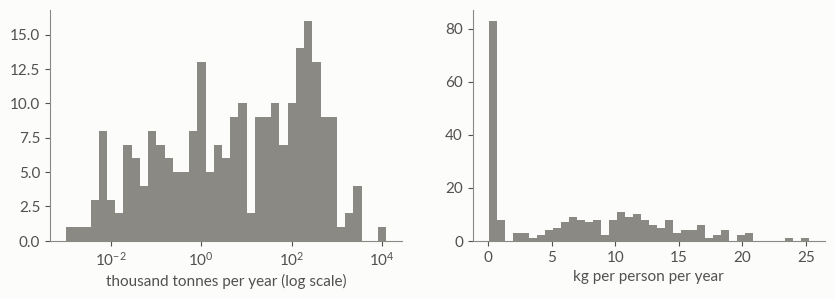

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(df["plastic_pollution_t"] / 1000, bins=np.logspace(-3, 4.1, 40), color=COLORS["ink_3"])
axes[0].set_xscale("log"); axes[0].set_xlabel("thousand tonnes per year (log scale)")
axes[1].hist(df["plastic_pollution_kg_per_cap"], bins=40, color=COLORS["ink_3"])
axes[1].set_xlabel("kg per person per year")
plt.show()

Totals are very skewed: a few countries emit millions of tonnes, many small ones only a few tonnes. So we use steps that grow by roughly ×5–10. Per person the spread is more even, from almost 0 to ~25 kg.

In [5]:
MAPS = {
    "total": dict(
        column="plastic_pollution_t", scale=1 / 1000,  # tonnes -> thousand tonnes
        bins=[0, 10, 50, 100, 500, 1000, np.inf],
        labels=["< 10", "10–50", "50–100", "100–500", "500–1,000", "> 1,000"],
        unit="thousand tonnes per year",
        low_col="plastic_pollution_t_p05", high_col="plastic_pollution_t_p95",
    ),
    "per_capita": dict(
        column="plastic_pollution_kg_per_cap", scale=1,
        bins=[0, 0.5, 2, 5, 10, 15, np.inf],
        labels=["< 0.5", "0.5–2", "2–5", "5–10", "10–15", "> 15"],
        unit="kg per person per year",
        low_col="plastic_pollution_kg_per_cap_p05", high_col="plastic_pollution_kg_per_cap_p95",
    ),
}


def classify(values, bins):
    """Return the class index (0..n-1) for each value, or -1 for missing."""
    idx = np.digitize(values, bins[1:-1], right=False)
    return np.where(np.isnan(values), -1, idx)

## Step 3: the figure: map on top, top-10 below

One function draws both versions, so 3a and 3b look the same. In the top-10 bar chart, the thin grey line on each bar shows the model's uncertainty (5th–95th percentile of 5,000 runs).

In [6]:
def pollution_map(kind, title, subtitle, top_title, top_filter=None, top_value_fmt="{:.1f}", top_scale=1, top_unit=""):
    cfg = MAPS[kind]
    fig = plt.figure(figsize=(7.28, 8.4))
    add_title(fig, title, subtitle)

    # --- legend: a row of colour boxes
    lx, ly, w = 0.04, 0.815, 0.085
    fig.text(lx, ly + 0.03, cfg["unit"].capitalize(), fontsize=9.5, color=COLORS["ink_2"])
    for i, (color, label) in enumerate(zip(MAP_RAMP, cfg["labels"])):
        fig.patches.append(Rectangle((lx + i * (w + 0.004), ly), w, 0.016, color=color,
                                     transform=fig.transFigure, figure=fig))
        fig.text(lx + i * (w + 0.004) + w / 2, ly - 0.008, label, ha="center", va="top", fontsize=8.8,
                 color=COLORS["ink_2"])
    fig.patches.append(Rectangle((lx + 6 * (w + 0.004) + 0.02, ly), 0.03, 0.016, color=COLORS["no_data"],
                                 transform=fig.transFigure, figure=fig))
    fig.text(lx + 6 * (w + 0.004) + 0.055, ly + 0.008, "no data", va="center", fontsize=8.8, color=COLORS["ink_2"])

    # --- the map
    ax = fig.add_axes([0.0, 0.42, 1.0, 0.37])
    values = world[cfg["column"]].to_numpy() * cfg["scale"]
    classes = classify(values, cfg["bins"])
    colors = [MAP_RAMP[c] if c >= 0 else COLORS["no_data"] for c in classes]
    world.plot(ax=ax, color=colors, edgecolor=COLORS["surface"], linewidth=0.3)
    ax.set_axis_off()

    # --- top 10 bars
    top = df if top_filter is None else df[top_filter(df)]
    top = top.nlargest(10, cfg["column"]).iloc[::-1]
    bx = fig.add_axes([0.30, 0.135, 0.52, 0.245])
    fig.text(0.04, 0.41, top_title, fontsize=12.5, fontweight="bold", va="top")
    val = top[cfg["column"]] * top_scale
    lo, hi = top[cfg["low_col"]] * top_scale, top[cfg["high_col"]] * top_scale
    bar_colors = [MAP_RAMP[c] for c in classify(top[cfg["column"]].to_numpy() * cfg["scale"], cfg["bins"])]
    bx.barh(range(10), val, color=bar_colors, height=0.66)
    bx.hlines(range(10), lo, hi, color=COLORS["ink_3"], linewidth=1.2, alpha=0.9)
    # values in one aligned column to the right, like a small table
    for y, v in zip(range(10), val):
        bx.text(1.02, y, top_value_fmt.format(v), va="center", ha="left", fontsize=10,
                fontweight="bold", color=COLORS["ink"], transform=bx.get_yaxis_transform())
    bx.set_yticks(range(10))
    bx.set_yticklabels(top["country"].replace({"Democratic Republic of the Congo": "DR Congo"}), fontsize=10)
    bx.tick_params(axis="y", length=0)
    bx.set_xticks([])
    bx.spines[["left", "bottom"]].set_visible(False)
    bx.set_xlim(0, hi.max() * 1.02)
    bx.text(1.0, -0.06, top_unit, transform=bx.transAxes, ha="right", va="top", fontsize=8.8,
            color=COLORS["ink_3"])
    return fig

### Figure 3a: total plastic pollution

saved figures/fig3a_pollution_map_total.png (+ .svg)


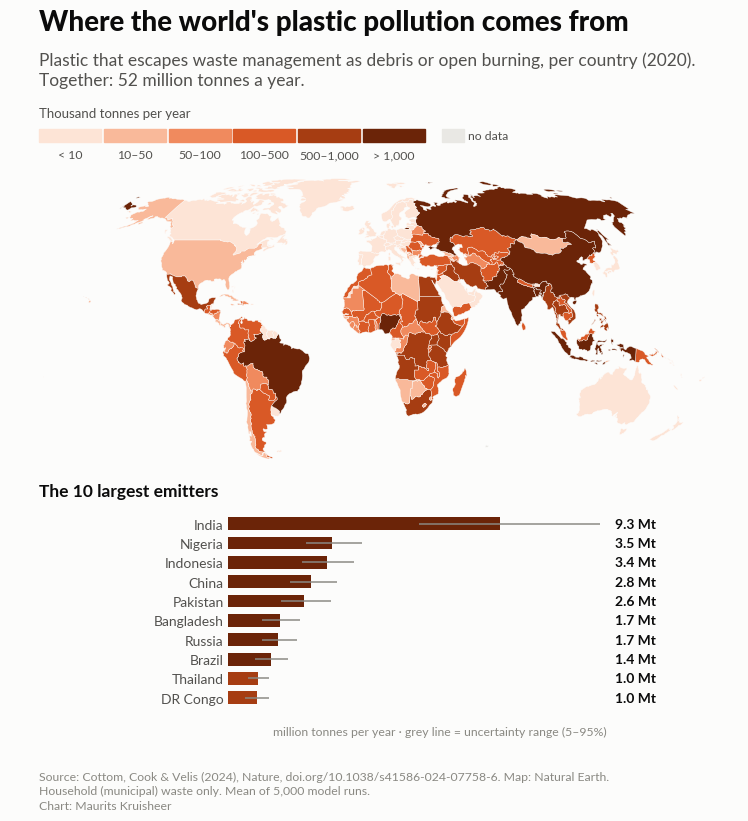

In [7]:
fig = pollution_map(
    "total",
    "Where the world's plastic pollution comes from",
    "Plastic that escapes waste management as debris or open burning, per country (2020).\n"
    "Together: 52 million tonnes a year.",
    top_title="The 10 largest emitters",
    top_scale=1 / 1e6, top_value_fmt="{:.1f} Mt",
    top_unit="million tonnes per year · grey line = uncertainty range (5–95%)",
)
add_footer(fig, "Cottom, Cook & Velis (2024), Nature, doi.org/10.1038/s41586-024-07758-6. Map: Natural Earth.",
           "Household (municipal) waste only. Mean of 5,000 model runs.")
save_figure(fig, "fig3a_pollution_map_total")
plt.show()

### Figure 3b: plastic pollution per person

Small territories can top a per-person ranking with very few people (the Paracel Islands have ~400 inhabitants). So for the top-10 we only include countries with at least 1 million people.

saved figures/fig3b_pollution_map_per_capita.png (+ .svg)


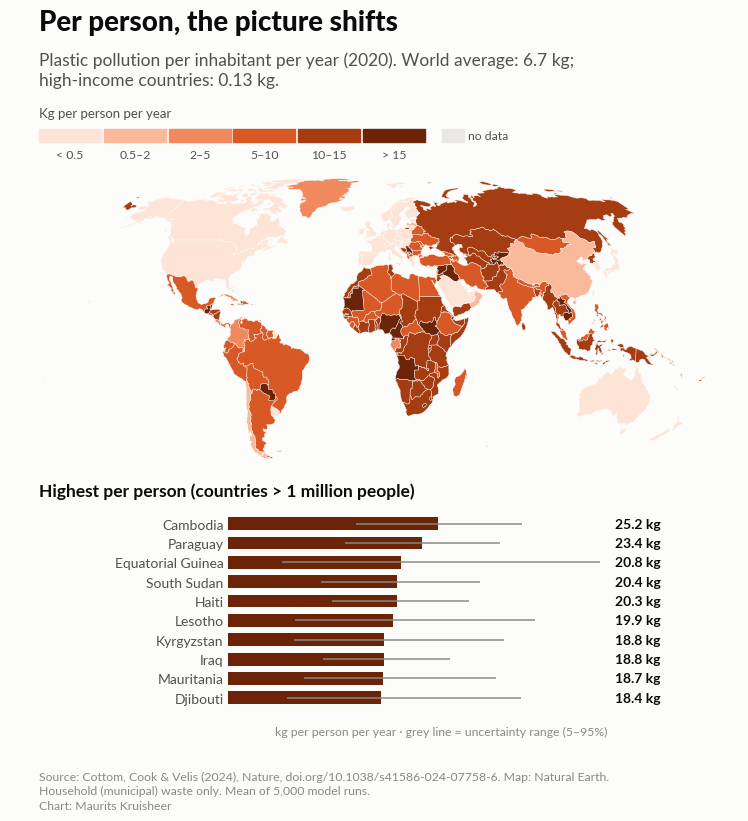

In [8]:
fig = pollution_map(
    "per_capita",
    "Per person, the picture shifts",
    "Plastic pollution per inhabitant per year (2020). World average: 6.7 kg;\n"
    "high-income countries: 0.13 kg.",
    top_title="Highest per person (countries > 1 million people)",
    top_filter=lambda d: d["population_2020"] >= 1_000_000,
    top_value_fmt="{:.1f} kg",
    top_unit="kg per person per year · grey line = uncertainty range (5–95%)",
)
add_footer(fig, "Cottom, Cook & Velis (2024), Nature, doi.org/10.1038/s41586-024-07758-6. Map: Natural Earth.",
           "Household (municipal) waste only. Mean of 5,000 model runs.")
save_figure(fig, "fig3b_pollution_map_per_capita")
plt.show()

## Step 4: export for an interactive Datawrapper map

In Datawrapper choose **Choropleth map → World**, upload this CSV, and match on the `ISO3` column. Set the colour steps to the same breaks we used above, and add the columns to the tooltip. Then paste the published link into Substack.

In [9]:
DW = ROOT / "datawrapper"
DW.mkdir(exist_ok=True)
export = pd.DataFrame({
    "ISO3": df["iso3"],
    "Country": df["country"],
    "Income group": df["income_group"].map({"HIC": "High income", "UMC": "Upper-middle income",
                                             "LMC": "Lower-middle income", "LIC": "Low income"}),
    "Population 2020": df["population_2020"],
    "Plastic pollution (thousand t/yr)": (df["plastic_pollution_t"] / 1000).round(1),
    "Low estimate (thousand t/yr)": (df["plastic_pollution_t_p05"] / 1000).round(1),
    "High estimate (thousand t/yr)": (df["plastic_pollution_t_p95"] / 1000).round(1),
    "Per person (kg/yr)": df["plastic_pollution_kg_per_cap"].round(2),
    "Share open burned (%)": (100 * df["open_burned_t"] / df["plastic_pollution_t"]).round(0),
})
export.to_csv(DW / "fig3_pollution_by_country.csv", index=False)
export.head(10)

,ISO3,Country,Income group,Population 2020,Plastic pollution (thousand t/yr),Low estimate (thousand t/yr),High estimate (thousand t/yr),Per person (kg/yr),Share open burned (%)
0,IND,India,Lower-middle income,1396453010,9276.0,6509.0,12680.0,6.64,62.0
1,NGA,Nigeria,Lower-middle income,208261372,3532.0,2645.0,4576.0,16.96,49.0
2,IDN,Indonesia,Lower-middle income,271016047,3352.0,2504.0,4289.0,12.37,58.0
3,CHN,China,Upper-middle income,1423731552,2808.0,2103.0,3709.0,1.97,58.0
4,PAK,Pakistan,Lower-middle income,227180827,2567.0,1786.0,3520.0,11.30,51.0
5,BGD,Bangladesh,Lower-middle income,167132312,1748.0,1135.0,2446.0,10.46,50.0
6,RUS,Russia,Upper-middle income,145353329,1702.0,1133.0,2351.0,11.71,84.0
7,BRA,Brazil,Upper-middle income,213090622,1445.0,902.5,2052.0,6.78,72.0
8,THA,Thailand,Upper-middle income,71462588,995.7,653.1,1379.0,13.93,80.0
9,COD,Democratic Republic of the Congo,Low income,92925478,963.3,573.7,1402.0,10.37,34.0


## Try it yourself

* Find your own country: `df[df["country"] == "Netherlands"]`. How does it compare with the world average of 6.7 kg per person?
* Change the class breaks in `MAPS`. How much does the story of the map change? (Class breaks are one of the easiest ways to make a map say what you want, so always check them.)
* Map the **share of open burning** (`open_burned_t / plastic_pollution_t`) instead. Where does most plastic pollution go up in smoke?